In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

rng = np.random.default_rng(2107)
N = 250

In [3]:
# ----------------------------------------------------------------------------
# BUILD website_ratings.csv
# ----------------------------------------------------------------------------
# A latent "satisfaction" makes the review columns positively correlated
sat = rng.normal(0, 1, N)

def review(weight, spread=0.8):
    return np.clip(np.round(3 + sat * weight + rng.normal(0, spread, N)), 1, 5).astype(int)

Ucredit = review(0.9)
Ureview = review(0.9)
Web_review = review(0.8)
Exp_review = review(1.0)
consecutive_usage = np.clip(np.round(5 + sat * 1.5 + rng.normal(0, 1.2, N)), 1, 10).astype(int)

# overall assigned rating, roughly tracking satisfaction
assigned_rating = np.clip(np.round(3 + sat * 1.1 + rng.normal(0, 0.6, N)), 1, 5).astype(int)
# the metric used (one clearly most common)
assigned_metric = rng.choice(["Weighted", "Mean", "Bayesian", "Median"],
                             size=N, p=[0.45, 0.30, 0.15, 0.10])

# product purchases from a shared pool (so products repeat across users)
pool = [f"P{100 + i}" for i in range(30)]
def products(prob_present):
    out, rats = [], []
    for _ in range(N):
        if rng.random() < prob_present:
            out.append(rng.choice(pool))
            rats.append(int(rng.integers(1, 6)))
        else:
            out.append(np.nan); rats.append(np.nan)
    return out, rats

p1, r1 = products(1.00)      # everyone makes a first purchase
p2, r2 = products(0.85)
p3, r3 = products(0.62)

df = pd.DataFrame({
    "userid": [f"U{1000 + i}" for i in range(N)],
    "Ucredit": Ucredit, "Ureview": Ureview, "Web_review": Web_review,
    "consecutive_usage": consecutive_usage, "Exp_review": Exp_review,
    "assigned_metric": assigned_metric, "assigned_rating": assigned_rating,
    "Product_1": p1, "rating_1": r1, "product_2": p2, "rating_2": r2,
    "product_3": p3, "rating_3": r3,
})
df.to_csv(f"website_ratings.csv", index=False)
print("website_ratings.csv built:", df.shape)



website_ratings.csv built: (250, 14)


In [4]:
df.head()

,userid,Ucredit,Ureview,Web_review,consecutive_usage,Exp_review,assigned_metric,assigned_rating,Product_1,rating_1,product_2,rating_2,product_3,rating_3
0,U1000,2,1,3,3,2,Mean,1,P123,2,P124,5.0,P113,1.0
1,U1001,2,4,5,4,3,Weighted,3,P115,5,P100,1.0,NaN,NaN
2,U1002,3,4,3,5,4,Mean,4,P117,5,P125,1.0,P106,5.0
3,U1003,4,5,5,7,5,Mean,3,P107,3,NaN,NaN,P126,4.0
4,U1004,5,5,4,7,5,Weighted,4,P118,5,NaN,NaN,P102,5.0


In [6]:
# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4a  -  WEBSITE RATINGS")
print("=" * 70)
df = pd.read_csv(f"website_ratings.csv")

# ---- 4a.1  META-DATA -------------------------------------------------------
print("\n[1] Step1 - first 10 rows (subset of columns shown):")
print(df[["userid", "Ucredit", "Ureview", "Web_review",
          "assigned_metric", "assigned_rating"]].head(10).to_string(index=False))
print("\n    Step2 - dtype of each column:")
print(df.dtypes.to_string())
num_cols = df.select_dtypes(include="number").columns
non_num = df.select_dtypes(exclude="number").columns
print("\n    Step3 - numerical columns:", len(num_cols),
      "| non-numerical columns:", len(non_num))
print("    numerical:", list(num_cols))
print("    non-numerical:", list(non_num))
print("\n    Step4 - statistical summary (numerical):")
print(df.describe().round(2).to_string())


QUESTION 4a  -  WEBSITE RATINGS

[1] Step1 - first 10 rows (subset of columns shown):
userid  Ucredit  Ureview  Web_review assigned_metric  assigned_rating
 U1000        2        1           3            Mean                1
 U1001        2        4           5        Weighted                3
 U1002        3        4           3            Mean                4
 U1003        4        5           5            Mean                3
 U1004        5        5           4        Weighted                4
 U1005        4        1           4        Weighted                3
 U1006        1        2           2        Weighted                1
 U1007        1        2           3          Median                2
 U1008        1        3           2        Weighted                2
 U1009        4        2           2            Mean                2

    Step2 - dtype of each column:
userid                object
Ucredit                int64
Ureview                int64
Web_review           

In [7]:
# ---- 4a.2  average rating per user (Ucredit, Ureview, Web_review) ----------
df["avg_rating"] = df[["Ucredit", "Ureview", "Web_review"]].mean(axis=1).round(1)
print("\n[2] avg_rating column added (rounded to 1 dp). Sample:")
print(df[["Ucredit", "Ureview", "Web_review", "avg_rating"]].head(5).to_string(index=False))


[2] avg_rating column added (rounded to 1 dp). Sample:
 Ucredit  Ureview  Web_review  avg_rating
       2        1           3         2.0
       2        4           5         3.7
       3        4           3         3.3
       4        5           5         4.7
       5        5           4         4.7


In [8]:
# ---- 4a.3  distinct products purchased & rated -----------------------------
all_products = pd.concat([df["Product_1"], df["product_2"], df["product_3"]])
distinct = all_products.dropna().nunique()
print("\n[3] Number of distinct products purchased & rated:", distinct)



[3] Number of distinct products purchased & rated: 30


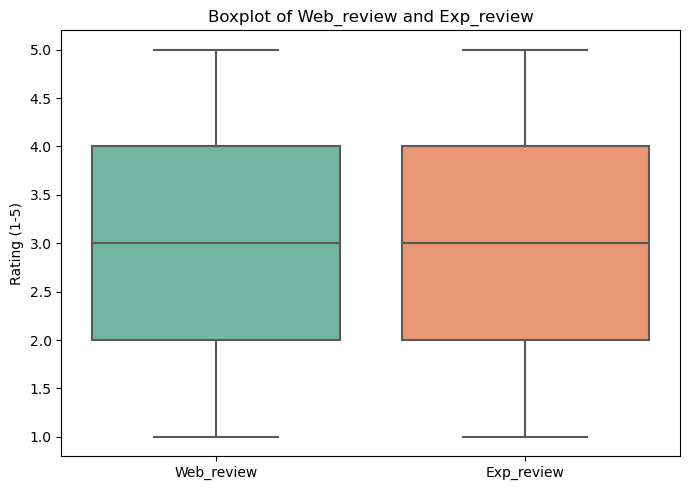


[4] Boxplot displayed (Web_review vs Exp_review)


In [10]:
# ---- 4a.4 boxplot of Web_review and Exp_review ----------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df[["Web_review", "Exp_review"]],
    palette="Set2"
)

plt.title("Boxplot of Web_review and Exp_review")
plt.ylabel("Rating (1-5)")

plt.tight_layout()
plt.show()

print("\n[4] Boxplot displayed (Web_review vs Exp_review)")

In [11]:
# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4b  -  METRICS, GROUPS & PLOTS")
print("=" * 70)

# ---- 4b.1  metric used for most ratings ------------------------------------
metric_counts = df["assigned_metric"].value_counts()
print("\n[1] Metric used for most ratings:", metric_counts.idxmax(),
      f"({metric_counts.max()} ratings)")
print(metric_counts.to_string())


QUESTION 4b  -  METRICS, GROUPS & PLOTS

[1] Metric used for most ratings: Weighted (113 ratings)
Weighted    113
Mean         66
Bayesian     41
Median       30


In [12]:
# ---- 4b.2  users with consecutive_usage > 4 + their avg user review --------
frequent = df[df["consecutive_usage"] > 4]
print("\n[2] Users with consecutive_usage > 4:", len(frequent))
print("    Their average user review (Ureview):", round(frequent["Ureview"].mean(), 2))


[2] Users with consecutive_usage > 4: 152
    Their average user review (Ureview): 3.42


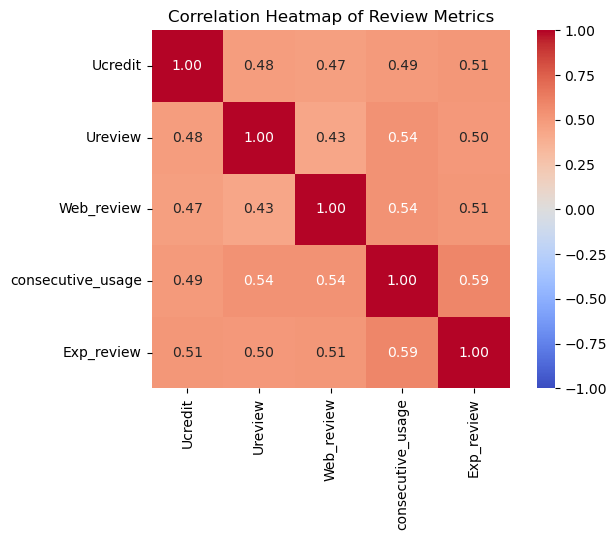


[3] Correlation matrix:
                   Ucredit  Ureview  Web_review  consecutive_usage  Exp_review
Ucredit               1.00     0.48        0.47               0.49        0.51
Ureview               0.48     1.00        0.43               0.54        0.50
Web_review            0.47     0.43        1.00               0.54        0.51
consecutive_usage     0.49     0.54        0.54               1.00        0.59
Exp_review            0.51     0.50        0.51               0.59        1.00


In [13]:
# ---- 4b.3 correlation heatmap ---------------------------------------------

cols = ["Ucredit", "Ureview", "Web_review", "consecutive_usage", "Exp_review"]

plt.figure(figsize=(7, 5.5))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Heatmap of Review Metrics")

plt.tight_layout()
plt.show()

print("\n[3] Correlation matrix:")
print(df[cols].corr().round(2).to_string())

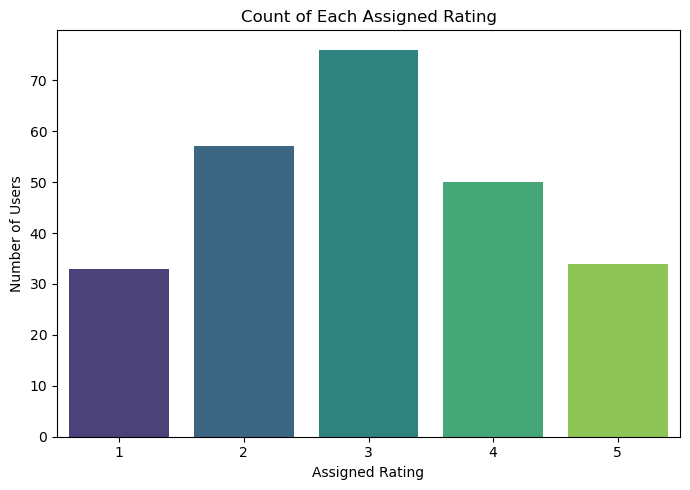


[4] assigned_rating counts:
1    33
2    57
3    76
4    50
5    34


In [14]:
# ---- 4b.4 count-plot of assigned_rating -----------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="assigned_rating",
    palette="viridis"
)

plt.title("Count of Each Assigned Rating")
plt.xlabel("Assigned Rating")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

print("\n[4] assigned_rating counts:")
print(df["assigned_rating"].value_counts().sort_index().to_string())

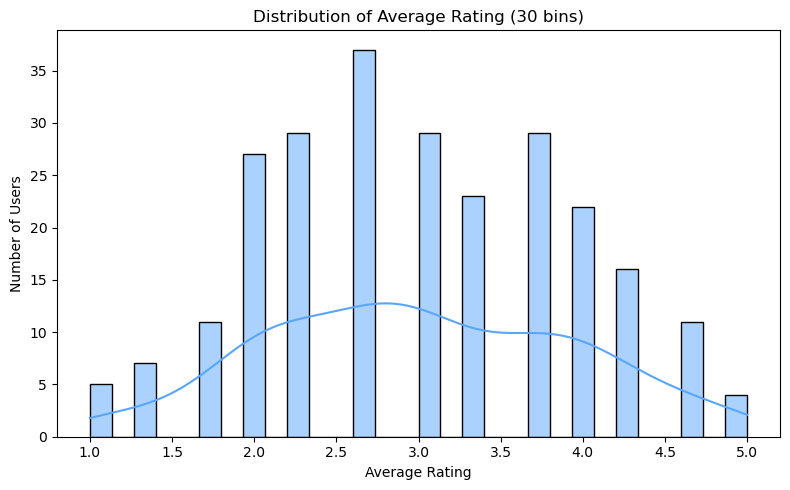


[5] avg_rating distribution displayed (30 bins)


In [15]:
# ---- 4b.5 distribution of avg_rating (30 bins) ----------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    df["avg_rating"],
    bins=30,
    kde=True,
    color="#58a6ff"
)

plt.title("Distribution of Average Rating (30 bins)")
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

print("\n[5] avg_rating distribution displayed (30 bins)")